In [1]:
#from thermostats import *
from thermostats_implemented import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

import numpy as np

class StreamingHistogram:
    def __init__(self, xmin, xmax, nbins):
        self.xmin = xmin
        self.xmax = xmax
        self.nbins = nbins

        self.bin_edges = np.linspace(xmin, xmax, nbins + 1)
        self.bin_width = (xmax - xmin) / nbins

        self.counts = np.zeros(nbins, dtype=float)
        self.total_count = 0  # counts all samples (including tails)

    def reset(self):
        self.counts[:] = 0.0
        self.total_count = 0

    def update(self, data):
        data = np.asarray(data)
        self.total_count += data.size

        hist, _ = np.histogram(data, bins=self.bin_edges)
        self.counts += hist

    def output(self):
        """
        Returns:
            bin_edges
            normalized_density (PDF per bin)
        """
        if self.total_count == 0:
            return None, None

        density = self.counts / (self.total_count * self.bin_width)
        return self.bin_edges, density

def test_thermostat(thermostat_func, T_target=2.0, T_init = 1.0):
    """
    Test that a thermostat reaches equilibrium at the target temperature.
    
    Parameters
    ----------
    thermostat_func : callable
        The thermostat function to test
    T_target : float
        The target temperature
    T_init : float
        The initial temperature
    """
    
    kB = 1.0
    mass = 1.0
    dt = 0.5
    nu = 1.0
    
    num_part = 20
    num_steps = 10
    num_samples = 5000
    
    # Start at different temperature
    rng = np.random.default_rng(seed=42)
    
    # Run thermostat for many steps to reach equilibrium
    
    histogram_init = StreamingHistogram(xmin=-5, xmax=5, nbins=50)
    histogram_final = StreamingHistogram(xmin=-5, xmax=5, nbins=50)
    temperature_init = []
    temperature_final = []
    
    # Equilibration phase
    temperature_mean = num_steps*[0.0]
    temperature_var = num_steps*[0.0]
    for _ in range(num_samples):
        #velocities = rng.normal(0.0, np.sqrt(kB * T_init/mass), size=(num_part, 3))
        velocities = rng.uniform(low=-np.sqrt(3*kB*T_init/mass), high=np.sqrt(3*kB*T_init/mass), size=(num_part, 3))
        histogram_init.update(velocities.ravel())
        T, _ = compute_temperature(velocities, mass, remove_com=True)
        temperature_mean[0] = temperature_mean[0] + T
        temperature_var[0] = temperature_var[0] + T*T
        temperature_init.append(T)
        for i in range(1,num_steps):
            # For stochastic thermostats, pass seed for reproducibility
            velocities = thermostat_func(
            velocities, mass, T_target, nu, dt, kB=kB)
            T, _ = compute_temperature(velocities, mass, remove_com=True)
            temperature_mean[i] = temperature_mean[i] + T
            temperature_var[i] = temperature_var[i] + T*T
        histogram_final.update(velocities.ravel())
        temperature_final.append(T)
    for i in range(num_steps):
        temperature_mean[i] = temperature_mean[i]/num_samples
        temperature_var[i] = temperature_var[i]/num_samples - temperature_mean[i]*temperature_mean[i]
    
    plt.plot(np.arange(num_steps)*dt, temperature_mean, label="Mean temperature")
    plt.fill_between(np.arange(num_steps)*dt, np.array(temperature_mean) - np.sqrt(temperature_var), np.array(temperature_mean) + np.sqrt(temperature_var), alpha=0.3, label="Temperature std")
    plt.xlabel("time")
    plt.ylabel("Temperature")
    plt.axhline(T_target, color='r', linestyle='--', label="Target temperature")
    plt.legend()
    plt.show()

    # Theoretical PDF for velocity components (Maxwell-Boltzmann distribution)
    pdf_v = lambda v, T: np.sqrt(mass/(2*np.pi*kB*T)) * np.exp(-mass*v**2/(2*kB*T))
    v_range = np.linspace(-5, 5, 200)
    plt.plot(v_range, pdf_v(v_range, T_init), 'r--', label="Theoretical initial pdf")
    edges, pdf = histogram_init.output()
    plt.step(edges[:-1], pdf, where="post", color='red', linewidth=2, label="initial")
    plt.plot(v_range, pdf_v(v_range, T_target), 'b--', label="Theoretical equilibrium pdf")
    edges, pdf = histogram_final.output()
    plt.step(edges[:-1], pdf, where="post", color='blue', linewidth=2, label="final")
    plt.xlabel("velocity")
    plt.ylabel("Probability density")   
    plt.legend()
    plt.show()
    
    # Theoretical PDF for kinetic temperature (chi-squared distribution)
    nu = (num_part-1) * 3  # subtract d if center of mass velocity is removed
    pdf_T = lambda T_k, T: chi2.pdf(T_k * nu / T, df=nu) * nu / T  # scale for temperature

    T_range = np.linspace(0.5, 3.5, 200)
    plt.hist(temperature_init, density=True, histtype='step', label="initial", bins=30, edgecolor='red', linewidth=2)
    plt.plot(T_range, pdf_T(T_range, T_init), 'r--', label="Theoretical initial pdf")
    plt.hist(temperature_final, density=True, histtype='step', label="final", bins=30, edgecolor='blue', linewidth=2)
    plt.plot(T_range, pdf_T(T_range, T_target), 'b--', label="Theoretical equilibrium pdf")
    plt.xlabel("Temperature")
    plt.ylabel("Probability density")
    plt.legend()
    plt.show()

    print(f"Target temperature:        {T_target:.4f}")
    print(f"Equilibrium mean:          {temperature_mean[-1]:.4f}")
    print(f"Equilibrium std:           {np.sqrt(temperature_var[-1]):.4f}")

Andersen thermostat test:


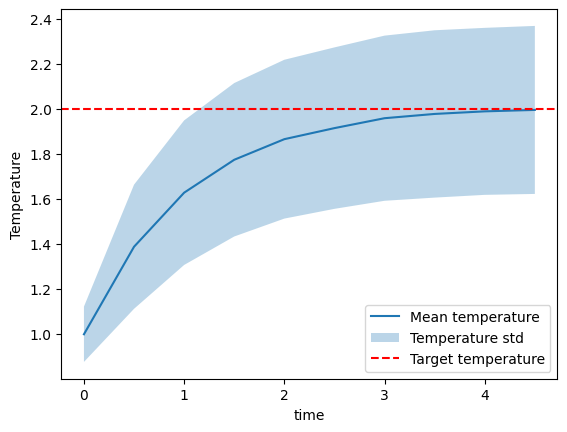

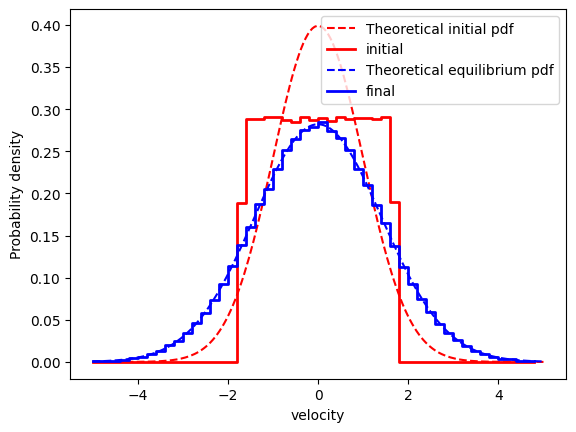

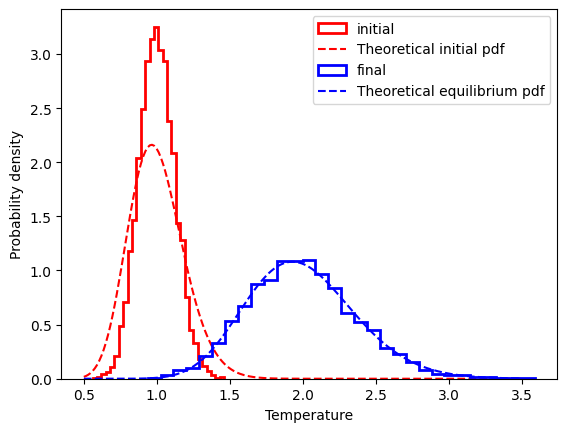

Target temperature:        2.0000
Equilibrium mean:          1.9949
Equilibrium std:           0.3730
Langevin thermostat test:


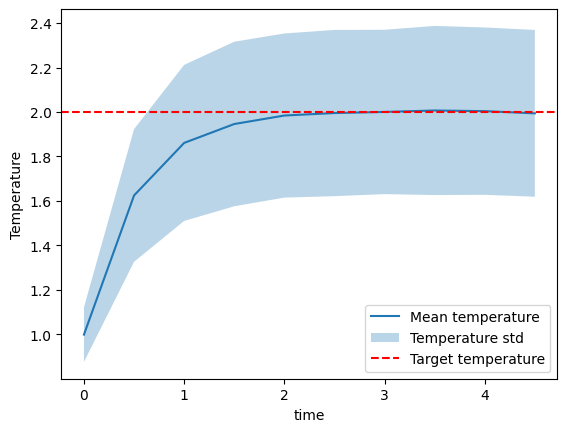

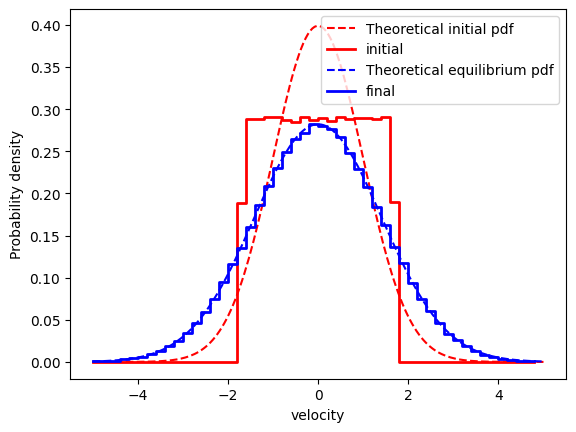

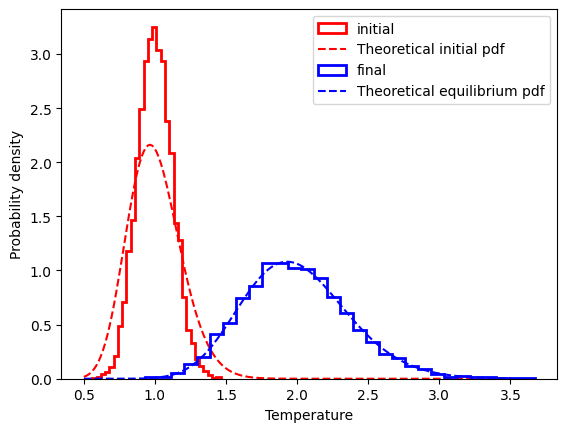

Target temperature:        2.0000
Equilibrium mean:          1.9940
Equilibrium std:           0.3751
Berendsen thermostat test:


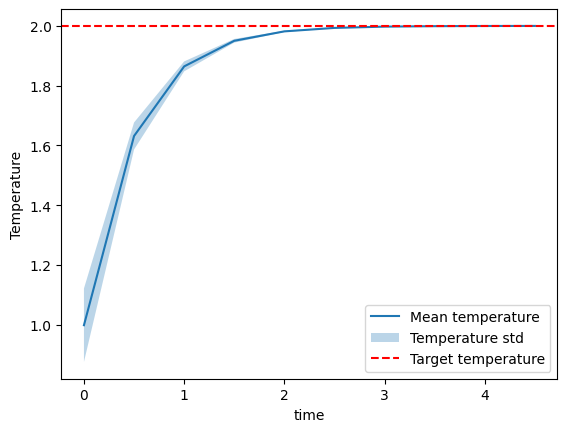

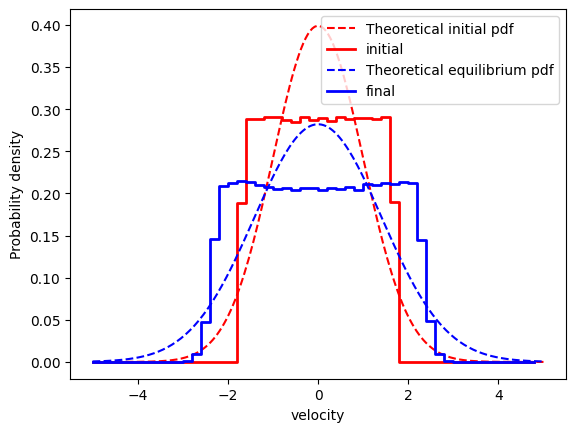

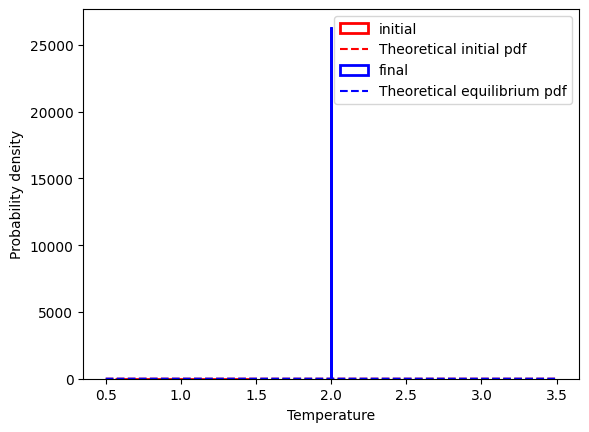

Target temperature:        2.0000
Equilibrium mean:          1.9999
Equilibrium std:           0.0000
Bussi thermostat test:


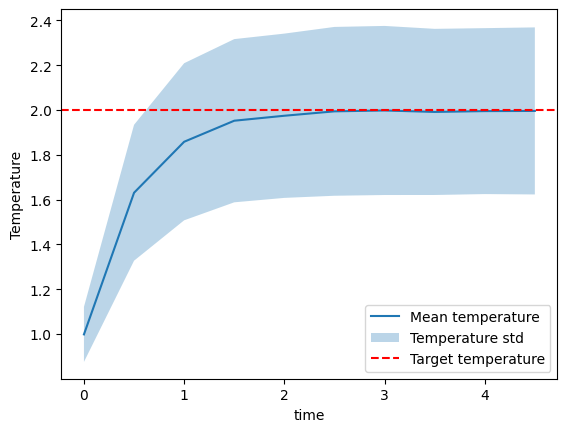

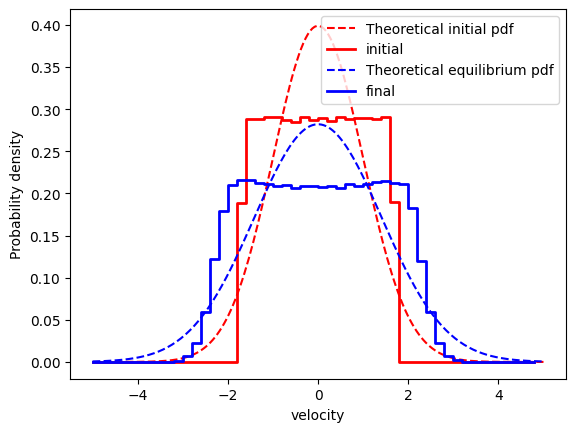

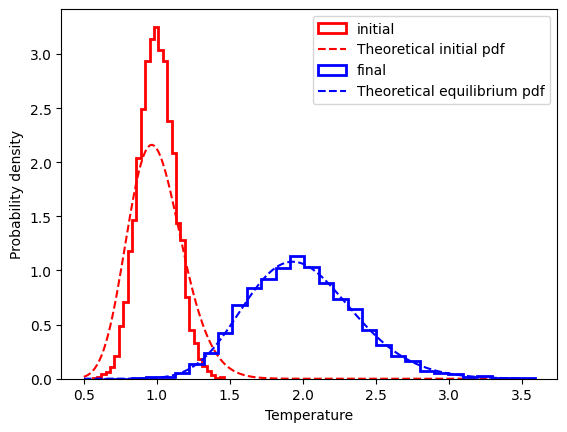

Target temperature:        2.0000
Equilibrium mean:          1.9957
Equilibrium std:           0.3727


In [4]:
print("Andersen thermostat test:")
test_thermostat(andersen_thermostat, T_target=2.0, T_init = 1.0)
print("Langevin thermostat test:")
test_thermostat(langevin_thermostat, T_target=2.0, T_init = 1.0)
print("Berendsen thermostat test:")
test_thermostat(berendsen_thermostat, T_target=2.0, T_init = 1.0)
print("Bussi thermostat test:")
test_thermostat(bussi_thermostat, T_target=2.0, T_init = 1.0)